In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("outputs/transformations", exist_ok=True)

Shape:  (1024, 1024, 3)
Dtype:  uint8


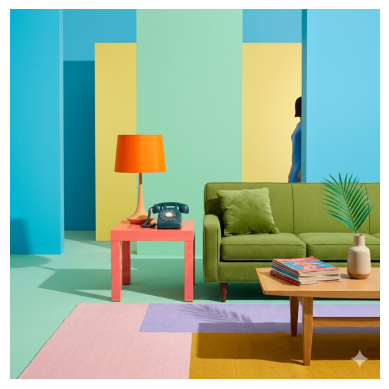

In [2]:
original_img = cv2.imread("images/livingroom.png")
if original_img is None:
    raise RuntimeError(f"It was not possible to find the {'images/livingroom.png'} image")
print("Shape: ", original_img.shape)
print("Dtype: ", original_img.dtype)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB), vmin=0, vmax=255)
plt.axis("off")
plt.show()

Shape smaller:  (512, 512, 3)
Shape bigger:  (2048, 2048, 3)
Shape fixed:  (480, 640, 3)
Deformed image


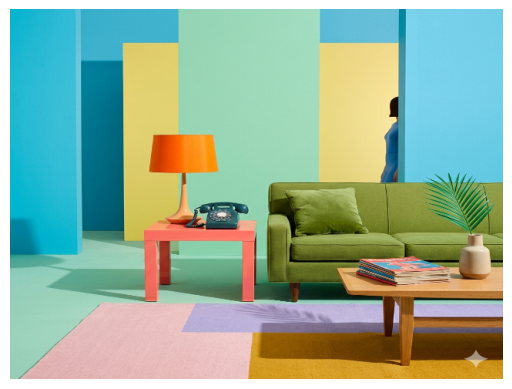

True

In [3]:
# Resize
smaller = cv2.resize(original_img, None, fx=0.5, fy=0.5)
bigger = cv2.resize(original_img, None, fx=2, fy=2)
fixed = cv2.resize(original_img, (640, 480))

print("Shape smaller: ", smaller.shape)
print("Shape bigger: ", bigger.shape)
print("Shape fixed: ", fixed.shape)

print("Deformed image")
plt.imshow(cv2.cvtColor(fixed, cv2.COLOR_BGR2RGB), vmin=0, vmax=255)
plt.axis("off")
plt.show()

cv2.imwrite("outputs/transformations/smaller.png", smaller)
cv2.imwrite("outputs/transformations/bigger.png", bigger)
cv2.imwrite("outputs/transformations/deformed.png", fixed)

In [4]:
# resize image to width 800 keeping aspect radio
image_2 = cv2.imread("images/thermal_image_1.png")
if image_2 is None:
    raise RuntimeError("Failed to read the image")

def resize_to_width_800(img):

    fixed_width = 800
    aspect_ratio = img.shape[0] / img.shape[1]
    new_height = int(round(aspect_ratio * fixed_width, 0))
    print(new_height)
    resized = cv2.resize(img, (fixed_width, new_height))
    return resized

resized_img_1 = resize_to_width_800(original_img)
resized_img_2 = resize_to_width_800(image_2)

print("Shape 1: ", resized_img_1.shape)
print("Shape 2: ", resized_img_2.shape)

cv2.imwrite("outputs/transformations/img_1_resize_width_800.png", resized_img_1)
cv2.imwrite("outputs/transformations/img_2_resize_width_800.png", resized_img_2)


800
511
Shape 1:  (800, 800, 3)
Shape 2:  (511, 800, 3)


True

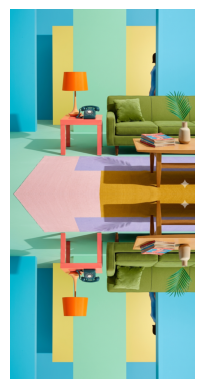

True

In [5]:
# flipping image and showing it side by side

flip_vertical = cv2.flip(original_img, 1)
flip_horizontal = cv2.flip(original_img, 0)
flip_both = cv2.flip(original_img, -1)

cv2.imwrite("outputs/transformations/flip_vertical.png", flip_vertical)
cv2.imwrite("outputs/transformations/flip_horizontal.png", flip_horizontal)
cv2.imwrite("outputs/transformations/flip_both.png", flip_both)

horizontal_mirrored_image = np.vstack((original_img, flip_horizontal))

plt.imshow(cv2.cvtColor(horizontal_mirrored_image, cv2.COLOR_BGR2RGB), vmin=0, vmax=255)
plt.axis("off")
plt.show()

cv2.imwrite("outputs/transformations/mirrored_horizontal.png", horizontal_mirrored_image)

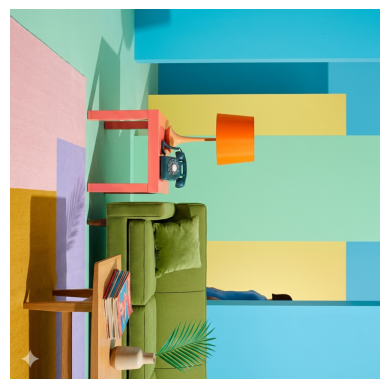

True

In [6]:
# Rotation

rot90 = cv2.rotate(original_img, cv2.ROTATE_90_CLOCKWISE)
rot270 = cv2.rotate(original_img, cv2.ROTATE_90_COUNTERCLOCKWISE)
rot180 = cv2.rotate(original_img, cv2.ROTATE_180)
plt.imshow(cv2.cvtColor(rot90, cv2.COLOR_BGR2RGB), vmin=0, vmax=255)
plt.axis("off")
plt.show()

cv2.imwrite("outputs/transformations/rotated_270.png", rot270)

In [9]:
# Rotate by an arbitrary angle

# find center of the image
(h, w) = original_img.shape[:2]
center = (w // 2, h // 2)

matrix = cv2.getRotationMatrix2D(center, 30, 1.0)
rotated_30 = cv2.warpAffine(original_img, matrix, (w, h))

cv2.imwrite("outputs/transformations/rotated_30.png", rotated_30)

# challenge -45, 15, 90

def rotate_about_the_center(image, deg):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, deg, 1.0)
    rotated = cv2.warpAffine(image, matrix, (w, h))
    cv2.imwrite(f"outputs/transformations/rotated_{str(deg)}.png", rotated)

rotate_about_the_center(original_img, -45) #normally rotated to the left but in this case it means rotate to the right
rotate_about_the_center(original_img, 15)
rotate_about_the_center(original_img, 90)

In [10]:
# Translation
(h, w) = original_img.shape[:2]

# translation in pixels
tx = 100
ty = 50

matrix = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])

translated = cv2.warpAffine(original_img, matrix, (w, h))
cv2.imwrite("outputs/transformations/translated.png", translated)

True

In [11]:
# brightness
# with convertScaleAbs we apply the following operation output = |input · alpha + beta| and clip to [0, 255]
brighter = cv2.convertScaleAbs(original_img, alpha=1.0, beta=50)
darker = cv2.convertScaleAbs(original_img, alpha=1.0, beta=-50)
cv2.imwrite("outputs/transformations/darker.png", darker)
cv2.imwrite("outputs/transformations/brighter.png", brighter)

True

In [13]:
# contrast
more_contrast = cv2.convertScaleAbs(original_img, alpha=1.2, beta=0)
less_contrast = cv2.convertScaleAbs(original_img, alpha=0.6, beta=0)
cv2.imwrite("outputs/transformations/more_contrast.png", more_contrast)
cv2.imwrite("outputs/transformations/less_contrast.png", less_contrast)

True

In [42]:
#stacked changes
base = cv2.resize(original_img, None, fx=0.5, fy=0.5)
small = cv2.resize(base, None, fx=0.5, fy=0.5)
small_canvas = np.zeros_like(base)
band = (small_canvas.shape[0] - small.shape[0]) // 2 # spaces at the canvas side to center image, same for h and w due to squared shape
print(base.shape[0])
small_canvas[band:small.shape[0] + band, band:small.shape[1] + band] = small

brighter = cv2.convertScaleAbs(base, alpha=1.0, beta=50)
darker = cv2.convertScaleAbs(base, alpha=1.0, beta=-50)
more_contrast = cv2.convertScaleAbs(base, alpha=1.2, beta=0)
less_contrast = cv2.convertScaleAbs(base, alpha=0.6, beta=0)

# translation
(h, w) = base.shape[:2]
tx = 100
ty = 25
matrix = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])
translated = cv2.warpAffine(base, matrix, (w, h))

# rotation
center = (w // 2, h // 2)
rotate_matrix = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated_45 = cv2.warpAffine(base, rotate_matrix, (w, h))

# flip
flipped = cv2.flip(base, 1)

# rotate
rotated = cv2.rotate(base, cv2.ROTATE_90_COUNTERCLOCKWISE)

for index, i in enumerate((base, brighter, darker, more_contrast, less_contrast, translated, rotated_45, small_canvas, rotated), start=1):
    print(f"{index}. {i.shape[:2]}")

row1 = np.hstack((base, brighter, darker))
row2 = np.hstack((more_contrast, less_contrast, translated))
row3 = np.hstack((rotated_45, small_canvas, rotated))

full_sheet = np.vstack((row1, row2, row3))
cv2.imwrite("outputs/transformations/comparisson.png", full_sheet)

512
1. (512, 512)
2. (512, 512)
3. (512, 512)
4. (512, 512)
5. (512, 512)
6. (512, 512)
7. (512, 512)
8. (512, 512)
9. (512, 512)


True